# Clasificación con Ingeniería de Características

En este notebook se aplicará **ingeniería de características** antes de entrenar los modelos.

En esta primera versión se aplicará principalmente:

- **Escalamiento / estandarización** de variables (feature scaling)

El objetivo es preparar un conjunto de entrenamiento y prueba transformado, listo para ser utilizado por modelos de clasificación.

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Carga de datos procesados

Se cargarán los conjuntos de entrenamiento y prueba generados previamente.

In [2]:
from pathlib import Path

data_dir = Path("mobile-price/processed")

train_df = pd.read_csv(data_dir / "train_split.csv")
test_df = pd.read_csv(data_dir / "test_split.csv")

X_train = train_df.drop(columns=["price_range"])
y_train = train_df["price_range"]

X_test = test_df.drop(columns=["price_range"])
y_test = test_df["price_range"]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1600, 20) (1600,)
Test: (400, 20) (400,)


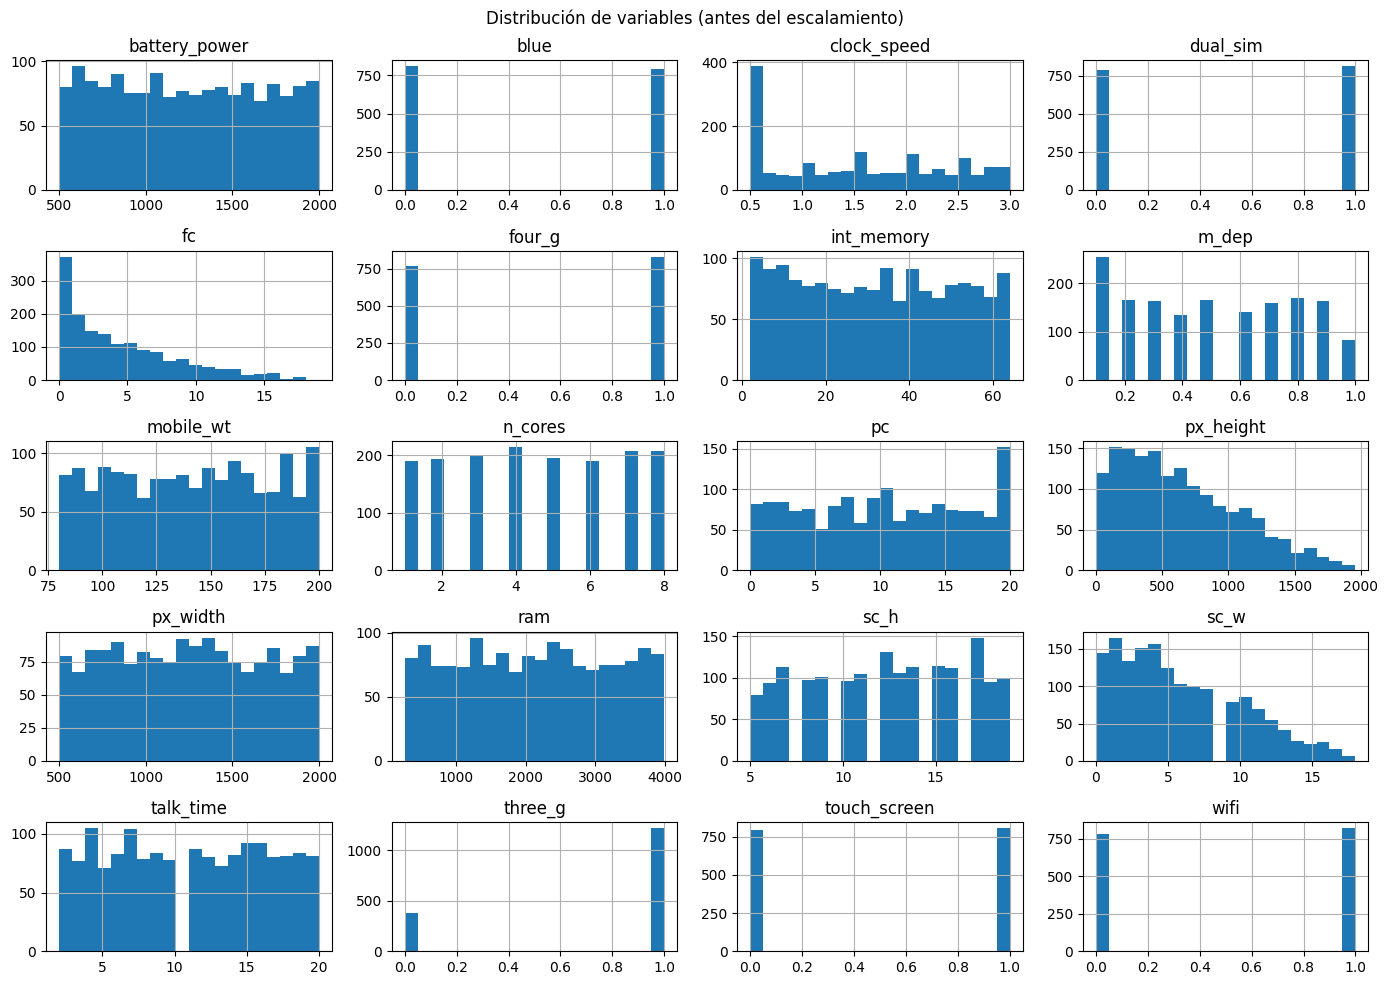

In [6]:
# Distribución de todas las variables antes del escalamiento

X_train.hist(
    figsize=(14,10),
    bins=20
)

plt.suptitle("Distribución de variables (antes del escalamiento)")
plt.tight_layout()
plt.show()

## Transformación de características: Escalamiento

Se aplicará escalamiento a las variables numéricas.

Esta transformación es especialmente relevante para modelos sensibles a escala, como:

- Perceptrón
- Regresión logística
- KNN
- SVM

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1.389193,1.011314,-1.259189,0.986343,1.309253,-1.036932,1.584829,-0.704590,-1.250335,-1.551637,0.350239,-0.798849,-1.285642,-0.363024,-0.781290,-0.177627,-0.896645,-1.788708,-1.008789,-1.025320
1,0.078406,1.011314,-1.259189,-1.013846,1.770460,-1.036932,-0.003457,-1.396849,-0.768374,1.073159,0.844549,1.582302,1.637675,-1.547896,0.647082,1.875207,0.560944,-1.788708,-1.008789,0.975305
2,-1.024573,-0.988813,1.187471,0.986343,-0.074370,0.964384,1.365755,1.372187,-1.392089,1.510625,0.350239,-1.361502,-0.199305,1.698985,-0.067104,0.506651,-0.896645,0.559063,0.991288,0.975305
3,0.386692,-0.988813,-1.259189,0.986343,-0.535577,0.964384,0.106080,1.026057,-1.193634,-0.676705,-0.803150,0.832847,0.278589,1.649232,-0.781290,0.506651,-1.625440,0.559063,-1.008789,0.975305
4,-0.723138,-0.988813,0.698139,0.986343,0.156234,-1.036932,-0.386837,-0.358460,-0.711673,1.073159,0.679779,-0.985650,-0.392794,-1.234632,-0.543228,0.278558,-1.078844,-1.788708,0.991288,0.975305


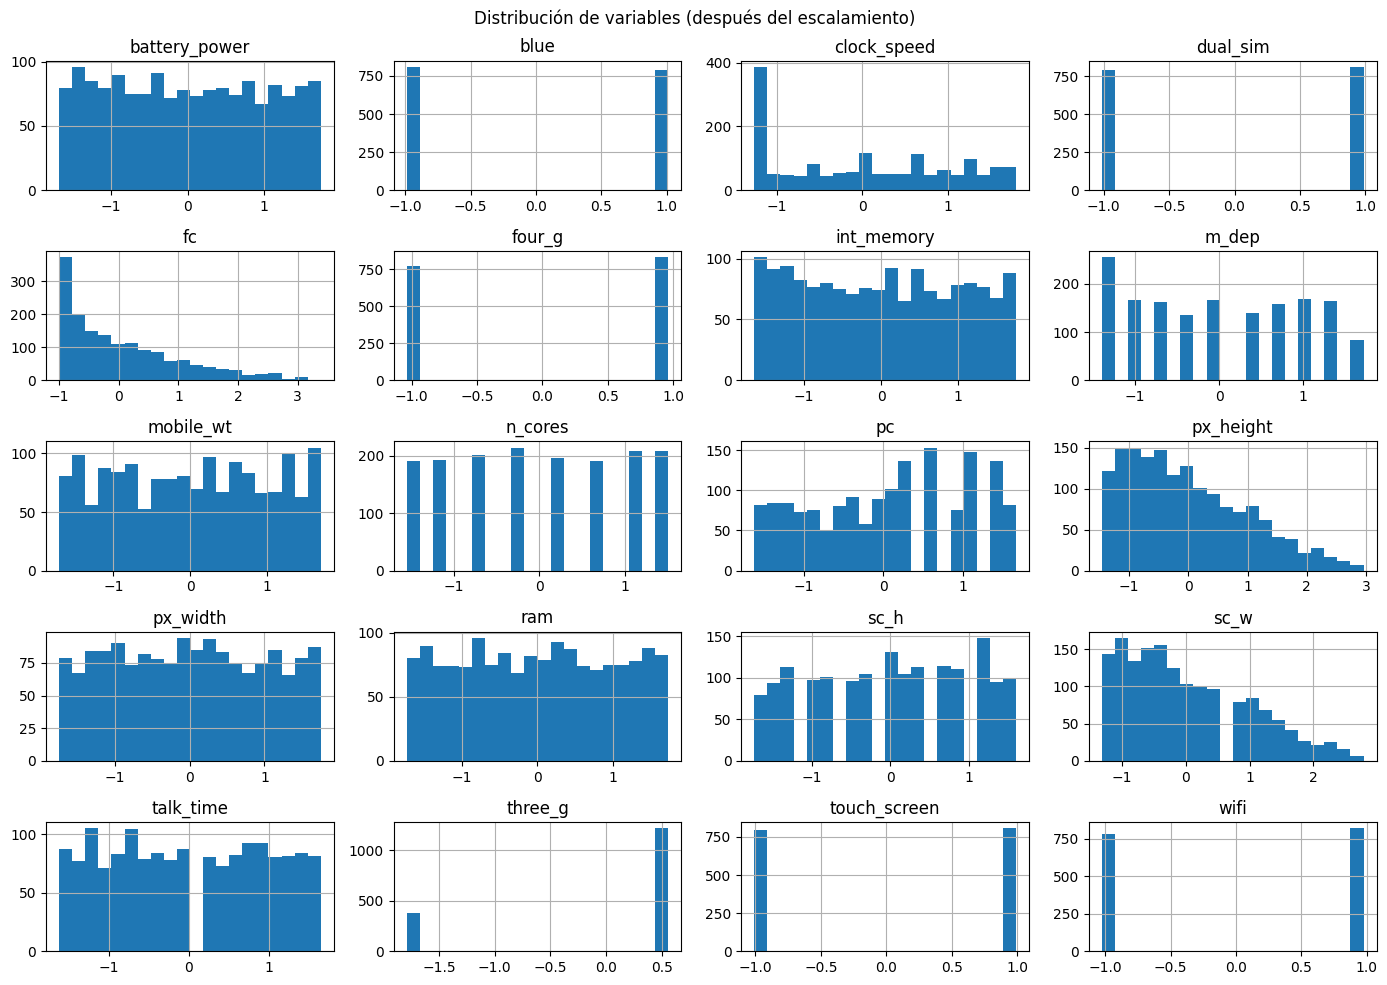

In [7]:
# Distribución de todas las variables después del escalamiento

X_train_scaled.hist(
    figsize=(14,10),
    bins=20
)

plt.suptitle("Distribución de variables (después del escalamiento)")
plt.tight_layout()
plt.show()

## Verificación rápida

Se revisará que la transformación haya dejado los datos centrados y con varianza comparable.

In [8]:
X_train_scaled.describe().loc[["mean", "std"]]

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
mean,-2.042810e-16,-6.661338e-18,-1.154632e-16,9.992007e-17,3.608225e-17,1.143530e-16,2.886580e-17,-1.154632e-16,2.264855e-16,-1.554312e-17,-9.103829e-17,4.440892e-17,2.609024e-16,-1.509903e-16,1.409983e-16,9.325873e-17,-1.026956e-16,1.532108e-16,-7.660539e-17,6.439294e-17
std,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00,1.000313e+00


# Entrenamiento y evaluación de modelos (con Ingeniería de Características)

En esta sección se entrenarán los mismos modelos utilizados anteriormente, pero ahora usando las variables transformadas mediante **escalamiento**.

Los modelos evaluados serán:

- Perceptrón
- Regresión Logística
- Árbol de Decisión

## Perceptrón

### Entrenamiento Perceptrón

In [10]:
perceptron_clf = Pipeline([
    ("model", Perceptron(random_state=42))
])

perceptron_clf.fit(X_train_scaled, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True


### Evaluación Perceptrón

Accuracy: 0.71
F1 macro: 0.7091776974801688

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       100
           1       0.52      0.43      0.47       100
           2       0.46      0.54      0.50       100
           3       0.91      0.88      0.89       100

    accuracy                           0.71       400
   macro avg       0.71      0.71      0.71       400
weighted avg       0.71      0.71      0.71       400



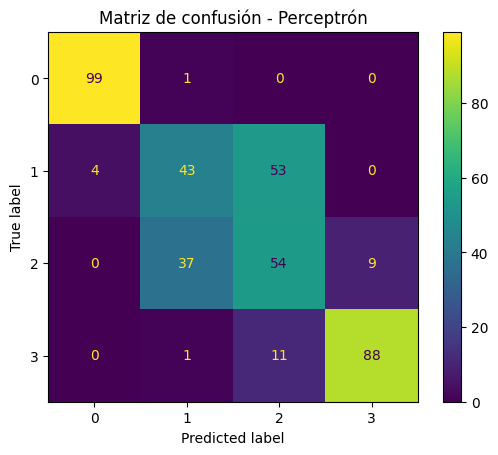

In [11]:
y_pred_p = perceptron_clf.predict(X_test_scaled)

acc_p = accuracy_score(y_test, y_pred_p)
f1_p = f1_score(y_test, y_pred_p, average="macro")

print("Accuracy:", acc_p)
print("F1 macro:", f1_p)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_p))

cm_p = confusion_matrix(y_test, y_pred_p)
disp_p = ConfusionMatrixDisplay(confusion_matrix=cm_p)
disp_p.plot()

plt.title("Matriz de confusión - Perceptrón")
plt.show()

## Regresión Logística

### Entrenamiento Regresión Logística

In [12]:
logreg_clf = Pipeline([
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

logreg_clf.fit(X_train_scaled, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=True

### Evaluación Regresión Logística

Accuracy: 0.965
F1 macro: 0.9649863177272501

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



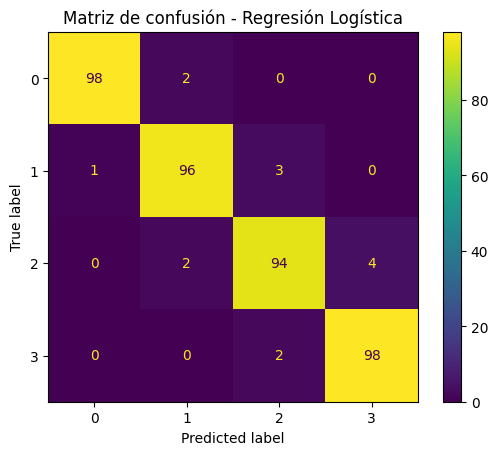

In [13]:
y_pred_lr = logreg_clf.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average="macro")

print("Accuracy:", acc_lr)
print("F1 macro:", f1_lr)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()

plt.title("Matriz de confusión - Regresión Logística")
plt.show()

## Árbol de Decisión

### Entrenamiento Árbol de Decisión

In [15]:
tree_clf = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_clf.fit(X_train_scaled, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If f

### Evaluación Árbol de Decisión

Accuracy: 0.83
F1 macro: 0.830168476083014

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.78      0.74      0.76       100
           2       0.75      0.80      0.77       100
           3       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



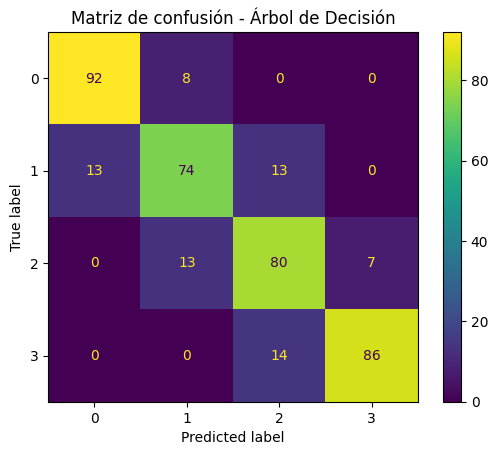

In [17]:
y_pred_dt = tree_clf.predict(X_test_scaled)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average="macro")

print("Accuracy:", acc_dt)
print("F1 macro:", f1_dt)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()

plt.title("Matriz de confusión - Árbol de Decisión")
plt.show()

# Comparación de resultados

In [19]:
results = pd.DataFrame({
    "Model": ["Perceptron", "Logistic Regression", "Decision Tree"],
    "Accuracy": [acc_p, acc_lr, acc_dt],
    "F1_macro": [f1_p, f1_lr, f1_dt]
})

results

,Model,Accuracy,F1_macro
0,Perceptron,0.710,0.709178
1,Logistic Regression,0.965,0.964986
2,Decision Tree,0.830,0.830168


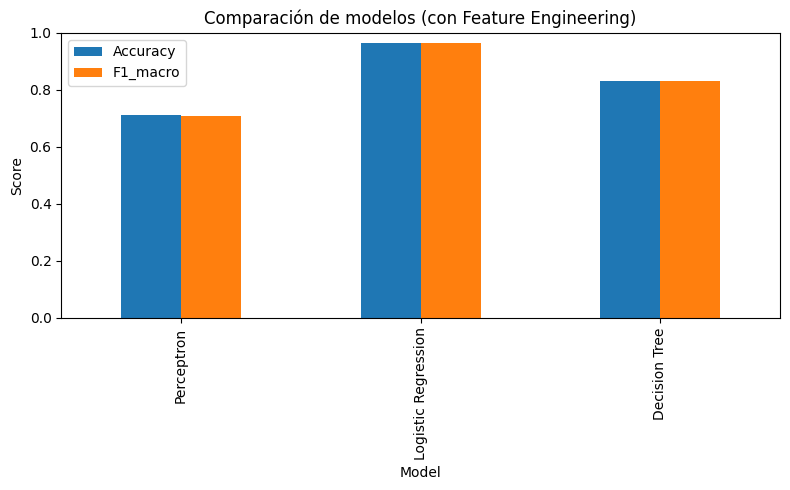

In [20]:
results.set_index("Model")[["Accuracy", "F1_macro"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparación de modelos (con Feature Engineering)")
plt.ylabel("Score")
plt.ylim(0,1)

plt.tight_layout()
plt.show()